# 03 Segment Uplift Analysis

This notebook explores whether the campaign effect differs across customer segments. Notebook 02 showed that the email treatments improved overall conversion and spend compared with the no-email control group. This notebook asks a more strategic question: should the company roll out the campaign broadly, or target specific customer groups?

The analysis is exploratory. Segment results help identify promising targeting strategies, but they should be interpreted more carefully than the primary experiment result because many subgroup comparisons are being reviewed.

## Analysis Questions

1. Which customer segments respond most strongly to each email treatment?
2. Are there segments where the campaign performs weakly or may not be worth targeting?
3. Does one treatment consistently outperform the other across segments?
4. What targeting recommendation should be carried into the final decision memo?

The main business metric is spend per customer lift versus the no-email control. Conversion lift is used as a supporting metric because it explains whether revenue improvement comes from more customers purchasing.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.config import CONTROL_GROUP, FIGURES_DIR, INTERIM_DATA_DIR, PROCESSED_DATA_DIR, RAW_DATA_PATH
from src.stat_tests import proportion_diff_ci, two_proportion_z_test

pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", "{:.4f}".format)

PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

PROJECT_ROOT

WindowsPath('E:/.projects/ab-testing')

## Load Data and Create Segment Fields

The notebook uses the cleaned dataset from the data audit step. I add a few analyst-friendly segment fields so the results are easier to interpret in business language.

In [2]:
clean_path = INTERIM_DATA_DIR / "email_ab_test_clean.csv"

if clean_path.exists():
    df = pd.read_csv(clean_path)
else:
    df = pd.read_csv(RAW_DATA_PATH)
    df["zip_code_clean"] = df["zip_code"].replace({"Surburban": "Suburban"})
    df["is_treatment"] = (df["segment"] != CONTROL_GROUP).astype(int)
    df["campaign_type"] = np.select(
        [df["segment"].eq("Mens E-Mail"), df["segment"].eq("Womens E-Mail"), df["segment"].eq(CONTROL_GROUP)],
        ["Mens", "Womens", "Control"],
        default="Unknown",
    )

analysis_df = df.copy()
analysis_df["customer_status"] = np.where(analysis_df["newbie"].eq(1), "New customer", "Returning customer")
analysis_df["product_affinity"] = np.select(
    [
        analysis_df["mens"].eq(1) & analysis_df["womens"].eq(1),
        analysis_df["mens"].eq(1) & analysis_df["womens"].eq(0),
        analysis_df["mens"].eq(0) & analysis_df["womens"].eq(1),
    ],
    ["Prior Mens and Womens", "Prior Mens only", "Prior Womens only"],
    default="No prior category flag",
)
analysis_df["recency_band"] = pd.cut(
    analysis_df["recency"],
    bins=[-np.inf, 3, 6, 9, np.inf],
    labels=["0-3 months", "4-6 months", "7-9 months", "10+ months"],
)

segment_variables = [
    "customer_status",
    "channel",
    "zip_code_clean",
    "history_segment",
    "product_affinity",
    "recency_band",
]

analysis_df[segment_variables + ["segment", "visit", "conversion", "spend"]].head()

,customer_status,channel,zip_code_clean,history_segment,product_affinity,recency_band,segment,visit,conversion,spend
0,Returning customer,Phone,Suburban,2) $100 - $200,Prior Mens only,10+ months,Womens E-Mail,0,0,0.0000
1,New customer,Web,Rural,3) $200 - $350,Prior Mens and Womens,4-6 months,No E-Mail,0,0,0.0000
2,New customer,Web,Suburban,2) $100 - $200,Prior Womens only,7-9 months,Womens E-Mail,0,0,0.0000
3,New customer,Web,Rural,5) $500 - $750,Prior Mens only,7-9 months,Mens E-Mail,0,0,0.0000
4,Returning customer,Web,Urban,1) $0 - $100,Prior Mens only,0-3 months,Womens E-Mail,0,0,0.0000


## Segment Method

For each segment category, I compare each email treatment against the `No E-Mail` control group within the same category.

For example, when analyzing `channel = Web`, the comparison is:

- Web customers who received `No E-Mail`
- Web customers who received `Mens E-Mail`
- Web customers who received `Womens E-Mail`

This keeps each comparison inside a like-for-like customer group. I require at least 500 customers in both the control and treatment subgroup before treating a segment result as stable enough for ranking.

In [3]:
def segment_uplift_table(data: pd.DataFrame, segment_columns: list[str], min_group_n: int = 500) -> pd.DataFrame:
    rows = []
    total_customers = len(data)
    treatment_groups = sorted(group for group in data["segment"].dropna().unique() if group != CONTROL_GROUP)

    for segment_column in segment_columns:
        for segment_value in sorted(data[segment_column].dropna().unique()):
            segment_data = data.loc[data[segment_column].eq(segment_value)].copy()
            control = segment_data.loc[segment_data["segment"].eq(CONTROL_GROUP)]
            if control.empty:
                continue

            for treatment_group in treatment_groups:
                treatment = segment_data.loc[segment_data["segment"].eq(treatment_group)]
                if treatment.empty:
                    continue

                control_n = len(control)
                treatment_n = len(treatment)
                control_conversions = int(control["conversion"].sum())
                treatment_conversions = int(treatment["conversion"].sum())
                control_visits = int(control["visit"].sum())
                treatment_visits = int(treatment["visit"].sum())

                conversion_test = two_proportion_z_test(control_conversions, control_n, treatment_conversions, treatment_n)
                conversion_ci = proportion_diff_ci(control_conversions, control_n, treatment_conversions, treatment_n)
                visit_test = two_proportion_z_test(control_visits, control_n, treatment_visits, treatment_n)
                visit_ci = proportion_diff_ci(control_visits, control_n, treatment_visits, treatment_n)
                spend_ttest = stats.ttest_ind(treatment["spend"], control["spend"], equal_var=False)

                control_spend = control["spend"].mean()
                treatment_spend = treatment["spend"].mean()
                spend_lift = treatment_spend - control_spend
                segment_share = len(segment_data) / total_customers

                rows.append(
                    {
                        "segment_variable": segment_column,
                        "segment_value": str(segment_value),
                        "treatment_group": treatment_group,
                        "segment_customers": len(segment_data),
                        "segment_share": segment_share,
                        "control_n": control_n,
                        "treatment_n": treatment_n,
                        "stable_sample": control_n >= min_group_n and treatment_n >= min_group_n,
                        "control_conversion_rate": conversion_test["rate_a"],
                        "treatment_conversion_rate": conversion_test["rate_b"],
                        "conversion_rate_lift": conversion_test["difference"],
                        "relative_conversion_lift": conversion_test["difference"] / conversion_test["rate_a"] if conversion_test["rate_a"] else np.nan,
                        "conversion_lift_ci_low": conversion_ci["ci_low"],
                        "conversion_lift_ci_high": conversion_ci["ci_high"],
                        "conversion_p_value": conversion_test["p_value"],
                        "control_visit_rate": visit_test["rate_a"],
                        "treatment_visit_rate": visit_test["rate_b"],
                        "visit_rate_lift": visit_test["difference"],
                        "visit_lift_ci_low": visit_ci["ci_low"],
                        "visit_lift_ci_high": visit_ci["ci_high"],
                        "visit_p_value": visit_test["p_value"],
                        "control_spend_per_customer": control_spend,
                        "treatment_spend_per_customer": treatment_spend,
                        "spend_per_customer_lift": spend_lift,
                        "relative_spend_lift": spend_lift / control_spend if control_spend else np.nan,
                        "spend_p_value": spend_ttest.pvalue,
                        "incremental_revenue_per_100k_segment_customers": spend_lift * 100_000,
                        "incremental_revenue_per_100k_total_customers_if_targeted": spend_lift * segment_share * 100_000,
                    }
                )

    return pd.DataFrame(rows)

segment_results = segment_uplift_table(analysis_df, segment_variables, min_group_n=500)
segment_results.head()

,segment_variable,segment_value,treatment_group,segment_customers,segment_share,control_n,treatment_n,stable_sample,control_conversion_rate,treatment_conversion_rate,conversion_rate_lift,relative_conversion_lift,conversion_lift_ci_low,conversion_lift_ci_high,conversion_p_value,control_visit_rate,treatment_visit_rate,visit_rate_lift,visit_lift_ci_low,visit_lift_ci_high,visit_p_value,control_spend_per_customer,treatment_spend_per_customer,spend_per_customer_lift,relative_spend_lift,spend_p_value,incremental_revenue_per_100k_segment_customers,incremental_revenue_per_100k_total_customers_if_targeted
0,customer_status,New customer,Mens E-Mail,32144,0.5022,10695,10686,True,0.0037,0.0111,0.0074,1.9775,0.0051,0.0097,0.0000,0.0788,0.1541,0.0753,0.0668,0.0838,0.0000,0.3724,1.3325,0.9600,2.5776,0.0000,96001.9842,48216.9966
1,customer_status,New customer,Womens E-Mail,32144,0.5022,10695,10763,True,0.0037,0.0090,0.0053,1.4097,0.0031,0.0074,0.0000,0.0788,0.1292,0.0504,0.0423,0.0586,0.0000,0.3724,1.1047,0.7323,1.9661,0.0000,73228.7796,36779.1545
2,customer_status,Returning customer,Mens E-Mail,31856,0.4978,10611,10621,True,0.0077,0.0139,0.0062,0.8032,0.0034,0.0090,0.0000,0.1337,0.2116,0.0778,0.0677,0.0879,0.0000,0.9354,1.5133,0.5780,0.6179,0.0094,57796.6905,28768.3027
3,customer_status,Returning customer,Womens E-Mail,31856,0.4978,10611,10624,True,0.0077,0.0087,0.0009,0.1206,-0.0015,0.0034,0.4514,0.1337,0.1739,0.0401,0.0304,0.0498,0.0000,0.9354,1.0493,0.1140,0.1218,0.5663,11395.7121,5672.2157
4,channel,Multichannel,Mens E-Mail,7762,0.1213,2606,2577,True,0.0069,0.0171,0.0102,1.4720,0.0042,0.0161,0.0008,0.1285,0.2115,0.0829,0.0626,0.1033,0.0000,0.6157,1.8249,1.2091,1.9637,0.0038,120912.9405,14664.4726


In [4]:
segment_results.to_csv(PROCESSED_DATA_DIR / "03_segment_uplift_all.csv", index=False)
segment_results.shape

(44, 28)

## Strongest Segment Opportunities

This table ranks stable segments by spend per customer lift. It emphasizes business impact, not only statistical significance. A segment is more attractive when it has positive spend lift, positive conversion lift, and enough customers to matter.

In [5]:
stable_positive = segment_results.loc[
    segment_results["stable_sample"]
    & segment_results["spend_per_customer_lift"].gt(0)
    & segment_results["conversion_rate_lift"].gt(0)
].copy()

stable_positive["opportunity_score"] = stable_positive["incremental_revenue_per_100k_total_customers_if_targeted"]

top_opportunities = stable_positive.sort_values(
    ["opportunity_score", "spend_per_customer_lift", "conversion_rate_lift"],
    ascending=False,
).head(15).reset_index(drop=True)

top_opportunities[[
    "segment_variable",
    "segment_value",
    "treatment_group",
    "segment_share",
    "control_n",
    "treatment_n",
    "conversion_rate_lift",
    "conversion_p_value",
    "spend_per_customer_lift",
    "spend_p_value",
    "incremental_revenue_per_100k_segment_customers",
    "incremental_revenue_per_100k_total_customers_if_targeted",
]]

,segment_variable,segment_value,treatment_group,segment_share,control_n,treatment_n,conversion_rate_lift,conversion_p_value,spend_per_customer_lift,spend_p_value,incremental_revenue_per_100k_segment_customers,incremental_revenue_per_100k_total_customers_if_targeted
0,customer_status,New customer,Mens E-Mail,0.5022,10695,10686,0.0074,0.0000,0.9600,0.0000,96001.9842,48216.9966
1,channel,Web,Mens E-Mail,0.4409,9373,9490,0.0072,0.0000,0.8504,0.0002,85044.8667,37495.4844
2,customer_status,New customer,Womens E-Mail,0.5022,10695,10763,0.0053,0.0000,0.7323,0.0000,73228.7796,36779.1545
3,recency_band,0-3 months,Mens E-Mail,0.3499,7438,7469,0.0073,0.0001,1.0476,0.0004,104759.8062,36654.4741
4,zip_code_clean,Suburban,Mens E-Mail,0.4496,9625,9501,0.0074,0.0000,0.8038,0.0005,80384.8102,36143.0203
5,product_affinity,Prior Mens only,Mens E-Mail,0.4503,9638,9558,0.0060,0.0000,0.6827,0.0021,68273.5312,30742.2910
6,zip_code_clean,Urban,Mens E-Mail,0.4010,8542,8563,0.0066,0.0000,0.7365,0.0007,73650.6819,29530.4710
7,customer_status,Returning customer,Mens E-Mail,0.4978,10611,10621,0.0062,0.0000,0.5780,0.0094,57796.6905,28768.3027
8,product_affinity,Prior Womens only,Womens E-Mail,0.4490,9519,9647,0.0051,0.0001,0.6316,0.0002,63164.7952,28359.0191
9,product_affinity,Prior Womens only,Mens E-Mail,0.4490,9519,9568,0.0057,0.0000,0.6157,0.0005,61573.0807,27644.3891


In [6]:
top_opportunities.to_csv(PROCESSED_DATA_DIR / "03_top_segment_opportunities.csv", index=False)

## Weak or Risky Segments

A campaign can be positive overall but less effective in specific groups. This section highlights stable segments with non-positive spend lift or non-positive conversion lift. These are candidates for exclusion, additional testing, or more cautious interpretation.

In [7]:
weak_segments = segment_results.loc[
    segment_results["stable_sample"]
    & (
        segment_results["spend_per_customer_lift"].le(0)
        | segment_results["conversion_rate_lift"].le(0)
    )
].copy()

weak_segments = weak_segments.sort_values(
    ["spend_per_customer_lift", "conversion_rate_lift"],
    ascending=True,
).reset_index(drop=True)

weak_segments[[
    "segment_variable",
    "segment_value",
    "treatment_group",
    "segment_share",
    "control_n",
    "treatment_n",
    "conversion_rate_lift",
    "spend_per_customer_lift",
    "conversion_p_value",
    "spend_p_value",
]].head(15)

,segment_variable,segment_value,treatment_group,segment_share,control_n,treatment_n,conversion_rate_lift,spend_per_customer_lift,conversion_p_value,spend_p_value
0,history_segment,3) $200 - $350,Womens E-Mail,0.1920,4044,4155,-0.0007,-0.3231,0.7092,0.2645
1,history_segment,4) $350 - $500,Womens E-Mail,0.1001,2124,2188,-0.0022,-0.1009,0.4807,0.7966


In [8]:
weak_segments.to_csv(PROCESSED_DATA_DIR / "03_weak_or_risky_segments.csv", index=False)

## Best Treatment by Segment

For each segment category, I select the treatment with the highest spend per customer lift. This is a simple targeting view: if the business had to choose one campaign per segment, which one currently looks strongest?

In [9]:
winner_rows = []
for (segment_variable, segment_value), group in segment_results.loc[segment_results["stable_sample"]].groupby(["segment_variable", "segment_value"]):
    winner = group.sort_values(["spend_per_customer_lift", "conversion_rate_lift"], ascending=False).iloc[0]
    winner_rows.append(winner)

segment_winners = pd.DataFrame(winner_rows).sort_values(
    "incremental_revenue_per_100k_total_customers_if_targeted",
    ascending=False,
).reset_index(drop=True)

segment_winners[[
    "segment_variable",
    "segment_value",
    "treatment_group",
    "segment_share",
    "conversion_rate_lift",
    "spend_per_customer_lift",
    "incremental_revenue_per_100k_segment_customers",
    "incremental_revenue_per_100k_total_customers_if_targeted",
]].head(20)

,segment_variable,segment_value,treatment_group,segment_share,conversion_rate_lift,spend_per_customer_lift,incremental_revenue_per_100k_segment_customers,incremental_revenue_per_100k_total_customers_if_targeted
0,customer_status,New customer,Mens E-Mail,0.5022,0.0074,0.9600,96001.9842,48216.9966
1,channel,Web,Mens E-Mail,0.4409,0.0072,0.8504,85044.8667,37495.4844
2,recency_band,0-3 months,Mens E-Mail,0.3499,0.0073,1.0476,104759.8062,36654.4741
3,zip_code_clean,Suburban,Mens E-Mail,0.4496,0.0074,0.8038,80384.8102,36143.0203
4,product_affinity,Prior Mens only,Mens E-Mail,0.4503,0.0060,0.6827,68273.5312,30742.2910
5,zip_code_clean,Urban,Mens E-Mail,0.4010,0.0066,0.7365,73650.6819,29530.4710
6,customer_status,Returning customer,Mens E-Mail,0.4978,0.0062,0.5780,57796.6905,28768.3027
7,product_affinity,Prior Womens only,Womens E-Mail,0.4490,0.0051,0.6316,63164.7952,28359.0191
8,channel,Phone,Mens E-Mail,0.4378,0.0055,0.5641,56407.4392,24696.7633
9,history_segment,1) $0 - $100,Womens E-Mail,0.3589,0.0038,0.6258,62581.9800,22461.0638


In [10]:
segment_winners.to_csv(PROCESSED_DATA_DIR / "03_best_treatment_by_segment.csv", index=False)

## Segment Rollup by Treatment

This view summarizes how often each treatment appears as the best option across stable segment categories. It helps determine whether one treatment is broadly stronger or whether the final recommendation should depend heavily on targeting.

In [11]:
winner_rollup = (
    segment_winners.groupby("treatment_group")
    .agg(
        winning_segments=("segment_value", "count"),
        avg_spend_lift=("spend_per_customer_lift", "mean"),
        avg_conversion_lift=("conversion_rate_lift", "mean"),
        total_revenue_opportunity_per_100k_total_customers=("incremental_revenue_per_100k_total_customers_if_targeted", "sum"),
    )
    .reset_index()
    .sort_values("winning_segments", ascending=False)
)
winner_rollup

,treatment_group,winning_segments,avg_spend_lift,avg_conversion_lift,total_revenue_opportunity_per_100k_total_customers
0,Mens E-Mail,17,0.9255,0.0083,392159.8282
1,Womens E-Mail,4,0.8022,0.0054,75442.5227


In [12]:
winner_rollup.to_csv(PROCESSED_DATA_DIR / "03_winner_rollup_by_treatment.csv", index=False)

## Visual Summary

The charts focus on the most actionable views: top revenue opportunities and best treatment by segment type.

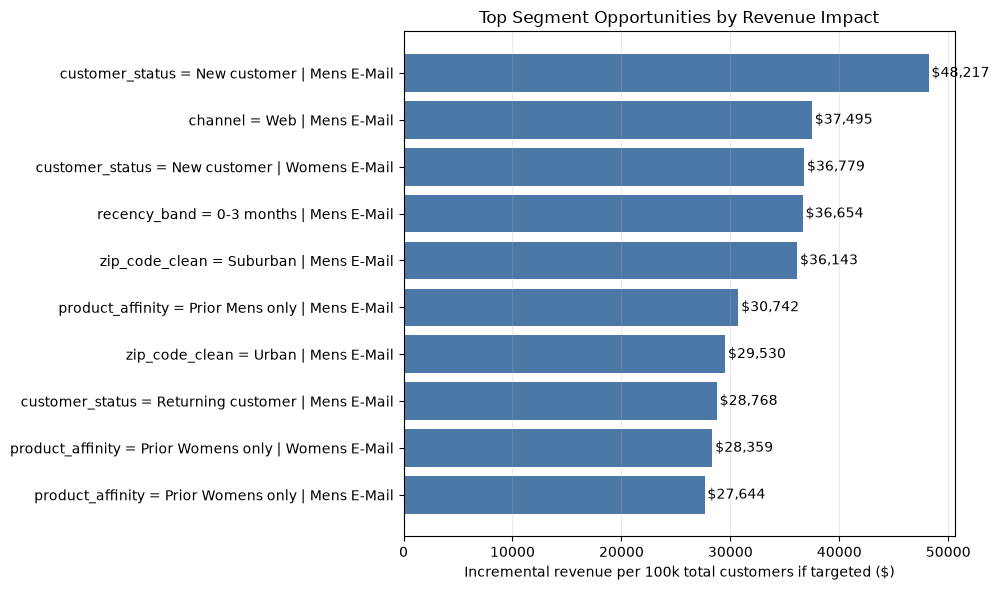

WindowsPath('E:/.projects/ab-testing/reports/figures/03_top_segment_opportunities.png')

In [13]:
plot_data = top_opportunities.head(10).copy()
plot_data["label"] = plot_data["segment_variable"] + " = " + plot_data["segment_value"] + " | " + plot_data["treatment_group"]
plot_data = plot_data.sort_values("incremental_revenue_per_100k_total_customers_if_targeted")

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(plot_data["label"], plot_data["incremental_revenue_per_100k_total_customers_if_targeted"], color="#4C78A8")
ax.set_title("Top Segment Opportunities by Revenue Impact")
ax.set_xlabel("Incremental revenue per 100k total customers if targeted ($)")
ax.grid(axis="x", alpha=0.25)
for i, value in enumerate(plot_data["incremental_revenue_per_100k_total_customers_if_targeted"]):
    ax.text(value + 250, i, f"${value:,.0f}", va="center")
plt.tight_layout()
top_segments_fig = FIGURES_DIR / "03_top_segment_opportunities.png"
plt.savefig(top_segments_fig, dpi=150)
plt.show()
top_segments_fig

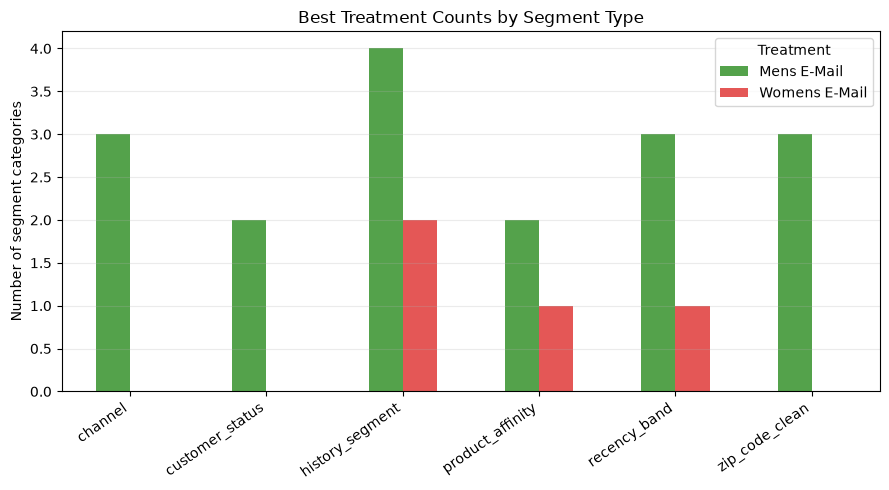

WindowsPath('E:/.projects/ab-testing/reports/figures/03_best_treatment_counts.png')

In [14]:
winner_count = segment_winners.groupby(["segment_variable", "treatment_group"]).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(9, 5))
winner_count.plot(kind="bar", ax=ax, color=["#54A24B", "#E45756"])
ax.set_title("Best Treatment Counts by Segment Type")
ax.set_ylabel("Number of segment categories")
ax.set_xlabel("")
ax.legend(title="Treatment")
ax.grid(axis="y", alpha=0.25)
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
winner_count_fig = FIGURES_DIR / "03_best_treatment_counts.png"
plt.savefig(winner_count_fig, dpi=150)
plt.show()
winner_count_fig

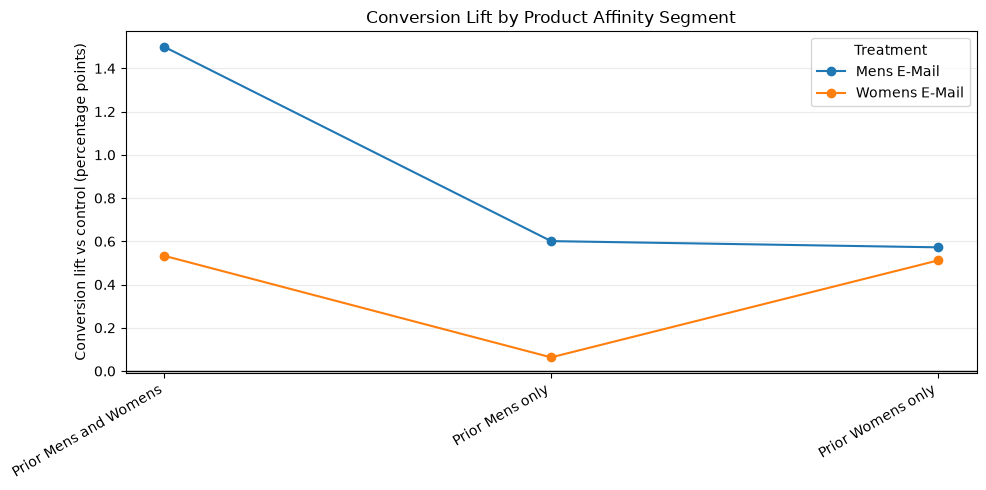

WindowsPath('E:/.projects/ab-testing/reports/figures/03_product_affinity_conversion_lift.png')

In [15]:
key_variable = "product_affinity"
key_data = segment_results.loc[
    segment_results["segment_variable"].eq(key_variable)
    & segment_results["stable_sample"]
].copy()
key_data["conversion_lift_pct_points"] = key_data["conversion_rate_lift"] * 100

fig, ax = plt.subplots(figsize=(10, 5))
for treatment_group, group in key_data.groupby("treatment_group"):
    ax.plot(group["segment_value"], group["conversion_lift_pct_points"], marker="o", label=treatment_group)
ax.axhline(0, color="black", linewidth=1)
ax.set_title("Conversion Lift by Product Affinity Segment")
ax.set_ylabel("Conversion lift vs control (percentage points)")
ax.set_xlabel("")
ax.legend(title="Treatment")
ax.grid(axis="y", alpha=0.25)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
affinity_fig = FIGURES_DIR / "03_product_affinity_conversion_lift.png"
plt.savefig(affinity_fig, dpi=150)
plt.show()
affinity_fig

## Targeting Interpretation

The final recommendation should combine the overall experiment result from notebook 02 with this segment analysis. If a treatment performs well overall and also appears strong across multiple large segments, it is a better rollout candidate. If a segment has weak or negative lift, it may need a different message, exclusion from rollout, or a follow-up test.

Because this segment analysis reviews many groups, I treat it as directional evidence for targeting rather than definitive proof for each subgroup.

In [16]:
best_overall_segment = top_opportunities.iloc[0]
rollup_winner = winner_rollup.iloc[0]
weak_count = len(weak_segments)

recommendation_lines = [
    "Segment targeting recommendation:",
    "",
    f"- The strongest individual opportunity is `{best_overall_segment['treatment_group']}` for `{best_overall_segment['segment_variable']} = {best_overall_segment['segment_value']}`.",
    f"- Estimated revenue impact for that segment: ${best_overall_segment['incremental_revenue_per_100k_segment_customers']:,.0f} per 100,000 customers within the segment.",
    f"- Adjusted for segment size, this equals about ${best_overall_segment['incremental_revenue_per_100k_total_customers_if_targeted']:,.0f} per 100,000 total customers.",
    f"- `{rollup_winner['treatment_group']}` appears most often as the best treatment across stable segment categories.",
    f"- {weak_count} stable treatment-segment combinations have weak or non-positive lift on either spend or conversion and should be reviewed before broad rollout.",
    "",
    "Decision note: use this analysis to shape targeting and follow-up tests, not as a replacement for the overall randomized experiment result.",
]
print("\n".join(recommendation_lines))

Segment targeting recommendation:

- The strongest individual opportunity is `Mens E-Mail` for `customer_status = New customer`.
- Estimated revenue impact for that segment: $96,002 per 100,000 customers within the segment.
- Adjusted for segment size, this equals about $48,217 per 100,000 total customers.
- `Mens E-Mail` appears most often as the best treatment across stable segment categories.
- 2 stable treatment-segment combinations have weak or non-positive lift on either spend or conversion and should be reviewed before broad rollout.

Decision note: use this analysis to shape targeting and follow-up tests, not as a replacement for the overall randomized experiment result.


## Notebook Outputs

This notebook writes the following reusable outputs:

- `data/processed/03_segment_uplift_all.csv`
- `data/processed/03_top_segment_opportunities.csv`
- `data/processed/03_weak_or_risky_segments.csv`
- `data/processed/03_best_treatment_by_segment.csv`
- `data/processed/03_winner_rollup_by_treatment.csv`
- `reports/figures/03_top_segment_opportunities.png`
- `reports/figures/03_best_treatment_counts.png`
- `reports/figures/03_product_affinity_conversion_lift.png`

Next notebook: `04_decision_memo_figures.ipynb`.